<a href="https://colab.research.google.com/github/Shubhranshu331/Polyp--Image_segmentation-UNET-/blob/main/Polyp_Image_Segmentation_UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polyp Image Segmentation — U-Net (TensorFlow / Keras)

**Dataset:** CVC-ClinicDB (colonoscopy polyp images)  
**Architecture:** Improved U-Net with Attention Gates  
**Framework:** TensorFlow 2.x / Keras  
**Environment:** Google Colab (GPU recommended)

---

## 1. Problem Statement

Automated polyp segmentation in colonoscopy images is a clinically important task — accurate detection and delineation of polyps can aid in early colorectal cancer diagnosis. In this project, I train a U-Net-based segmentation model on the CVC-ClinicDB dataset to produce binary segmentation masks that identify polyp regions in endoscopic images.

The focus is on:
- Clean, stable training with proper data handling
- Improved mask prediction quality using an attention-augmented U-Net
- Dice + Binary Cross-Entropy combined loss for better boundary learning
- Quantitative evaluation using Dice Coefficient and IoU

---
## 2. Install Dependencies & Import Libraries

In [1]:
# Install tifffile for reading .tif images (not pre-installed in all Colab environments)
!pip install tifffile -q

In [2]:
import os
import random
import numpy as np
import cv2
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    UpSampling2D, Concatenate, Multiply, Lambda, Dropout, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)

# Seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


---
## 3. Configuration

In [3]:
# ── Global config — change these if needed ──────────────────────────────
IMG_HEIGHT  = 256
IMG_WIDTH   = 256
IMG_CHANNELS = 3

BATCH_SIZE  = 8
EPOCHS      = 60
LR          = 1e-4

# Folder paths (auto-created)
BASE_DIR    = "/content"
DATA_DIR    = os.path.join(BASE_DIR, "local-dataset")
IMAGE_DIR   = os.path.join(DATA_DIR, "images")
MASK_DIR    = os.path.join(DATA_DIR, "masks")

SAVE_MODEL_DIR  = os.path.join(BASE_DIR, "saved_model")
PLOTS_DIR       = os.path.join(BASE_DIR, "plots")
OUTPUTS_DIR     = os.path.join(BASE_DIR, "outputs")

for d in [SAVE_MODEL_DIR, PLOTS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready.")
print(f"  saved_model/ → {SAVE_MODEL_DIR}")
print(f"  plots/       → {PLOTS_DIR}")
print(f"  outputs/     → {OUTPUTS_DIR}")

Directories ready.
  saved_model/ → /content/saved_model
  plots/       → /content/plots
  outputs/     → /content/outputs


---
## 4. Upload & Extract Dataset

Upload your dataset as a ZIP file. The ZIP should contain a `local-dataset/` folder with two sub-folders:
```
local-dataset/
├── images/   ← colonoscopy frames (.tif or .png)
└── masks/    ← binary segmentation masks (.tif or .png)
```

In [4]:
from google.colab import files

print("Please upload your dataset ZIP file...")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f"Uploaded: {zip_filename}")

Please upload your dataset ZIP file...


Saving local-dataset.zip to local-dataset.zip
Uploaded: local-dataset.zip


In [5]:
import zipfile

zip_path = os.path.join(BASE_DIR, zip_filename)

print(f"Extracting {zip_filename} ...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(BASE_DIR)

# Verify extraction
imgs  = sorted(glob(os.path.join(IMAGE_DIR, "*")))
masks = sorted(glob(os.path.join(MASK_DIR,  "*")))

print(f"\nExtraction complete.")
print(f"  Images found : {len(imgs)}")
print(f"  Masks  found : {len(masks)}")

if len(imgs) == 0:
    raise FileNotFoundError(
        f"No images found in {IMAGE_DIR}. "
        "Check that the ZIP extracts to local-dataset/images/ and local-dataset/masks/"
    )

Extracting local-dataset.zip ...

Extraction complete.
  Images found : 500
  Masks  found : 500


---
## 5. Dataset Split

In [6]:
# Sort both lists by filename stem so image[i] pairs with mask[i]
def sort_by_stem(paths):
    return sorted(paths, key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))

try:
    image_paths = sort_by_stem(imgs)
    mask_paths  = sort_by_stem(masks)
except ValueError:
    # Filenames are not purely numeric — fall back to alphabetical sort
    image_paths = sorted(imgs)
    mask_paths  = sorted(masks)

# Verify pairing
for ip, mp in zip(image_paths[:3], mask_paths[:3]):
    assert os.path.splitext(os.path.basename(ip))[0] ==            os.path.splitext(os.path.basename(mp))[0],            f"Mismatch: {ip} vs {mp}"

print(f"Pairing verified for first {min(3, len(image_paths))} samples.")

# 80 / 10 / 10 split
train_x, temp_x, train_y, temp_y = train_test_split(
    image_paths, mask_paths, test_size=0.20, random_state=SEED
)
val_x, test_x, val_y, test_y = train_test_split(
    temp_x, temp_y, test_size=0.50, random_state=SEED
)

print(f"\nSplit summary:")
print(f"  Train : {len(train_x):>4} images")
print(f"  Val   : {len(val_x):>4} images")
print(f"  Test  : {len(test_x):>4} images")

Pairing verified for first 3 samples.

Split summary:
  Train :  400 images
  Val   :   50 images
  Test  :   50 images


---
## 6. Preprocessing & Augmentation

In [7]:
def load_image(path):
    """Load an image (TIF or common formats) and return float32 RGB array."""
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.tif', '.tiff'):
        img = tifffile.imread(path)
    else:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Handle grayscale images
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 4:  # RGBA
        img = img[..., :3]

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    return img


def load_mask(path):
    """Load a mask and return a binary float32 array of shape (H, W, 1)."""
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.tif', '.tiff'):
        msk = tifffile.imread(path)
    else:
        msk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if msk.ndim == 3:
        msk = msk[..., 0]  # take first channel if multi-channel mask

    msk = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    msk = (msk > 127).astype(np.float32)
    return np.expand_dims(msk, axis=-1)


print("Loader functions defined.")

# Quick sanity check
_img = load_image(image_paths[0])
_msk = load_mask(mask_paths[0])
print(f"Sample image shape : {_img.shape}  range [{_img.min():.2f}, {_img.max():.2f}]")
print(f"Sample mask  shape : {_msk.shape}  unique values {np.unique(_msk)}")

Loader functions defined.
Sample image shape : (256, 256, 3)  range [0.00, 1.00]
Sample mask  shape : (256, 256, 1)  unique values [0. 1.]


In [8]:
def augment(image, mask):
    """Apply identical random augmentations to image and mask."""
    # Horizontal flip
    if random.random() > 0.5:
        image = np.fliplr(image)
        mask  = np.fliplr(mask)

    # Vertical flip
    if random.random() > 0.5:
        image = np.flipud(image)
        mask  = np.flipud(mask)

    # Random 90° rotation
    k = random.randint(0, 3)
    if k > 0:
        image = np.rot90(image, k)
        mask  = np.rot90(mask, k)

    # Brightness / contrast jitter (image only)
    if random.random() > 0.5:
        factor = random.uniform(0.8, 1.2)
        image  = np.clip(image * factor, 0, 1)

    return image, mask


def data_generator(image_list, mask_list, batch_size, augment_data=False):
    """Infinite generator yielding (batch_images, batch_masks)."""
    n = len(image_list)
    indices = list(range(n))

    while True:
        random.shuffle(indices)
        for start in range(0, n, batch_size):
            batch_idx = indices[start : start + batch_size]
            imgs, msks = [], []
            for i in batch_idx:
                img = load_image(image_list[i])
                msk = load_mask(mask_list[i])
                if augment_data:
                    img, msk = augment(img, msk)
                imgs.append(img)
                msks.append(msk)
            yield np.array(imgs, dtype=np.float32), np.array(msks, dtype=np.float32)


print("Data generator defined.")

Data generator defined.


---
## 7. Visualize Sample Data

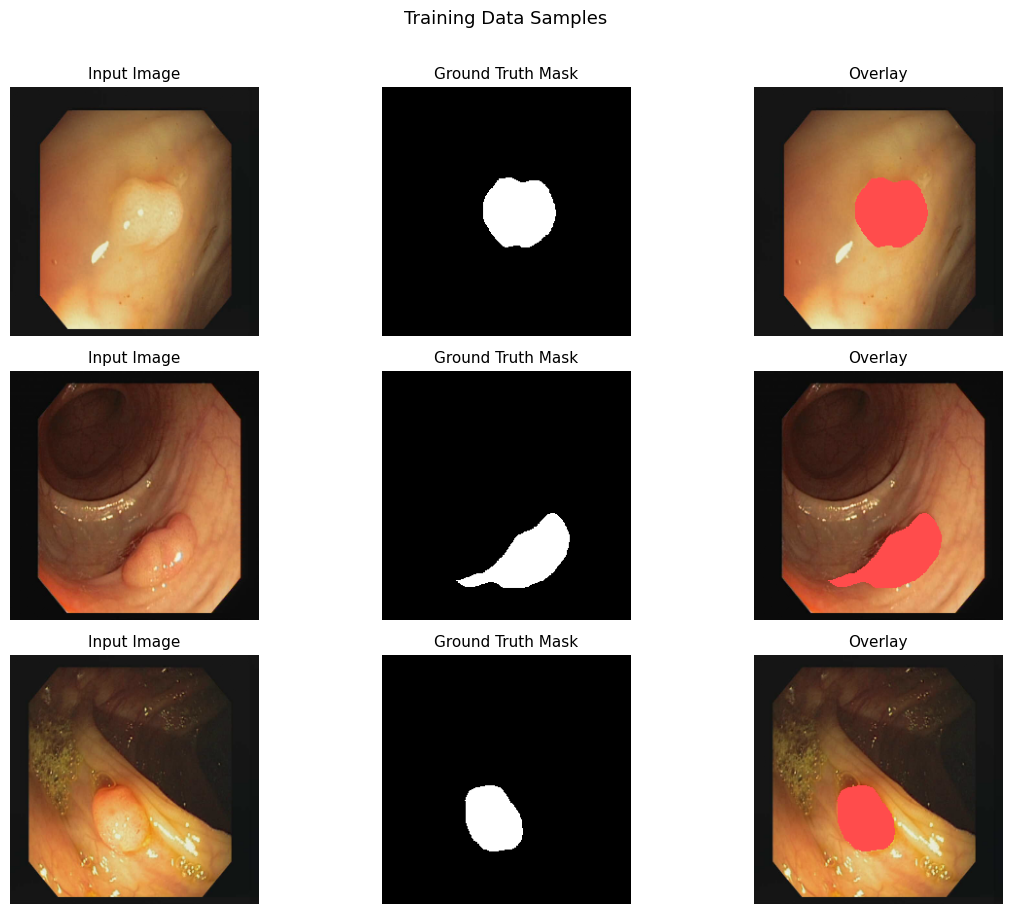

Saved → plots/sample_data.png


In [9]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
sample_idx = random.sample(range(len(train_x)), 3)

for row, idx in enumerate(sample_idx):
    img = load_image(train_x[idx])
    msk = load_mask(train_y[idx])

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Input Image", fontsize=11)

    axes[row, 1].imshow(msk.squeeze(), cmap="gray")
    axes[row, 1].set_title("Ground Truth Mask", fontsize=11)

    overlay = img.copy()
    overlay[msk.squeeze() > 0.5] = [1.0, 0.3, 0.3]
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay", fontsize=11)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Training Data Samples", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "sample_data.png"), bbox_inches="tight", dpi=120)
plt.show()
print("Saved → plots/sample_data.png")

---
## 8. Model Architecture — Attention U-Net

The base architecture is a standard U-Net (encoder-decoder with skip connections). I've added **attention gates** on each skip connection: they suppress irrelevant background features before merging with the decoder, which directly improves boundary precision and reduces false positives.

Key improvements over the original notebook:
- Attention gates on skip connections → sharper boundaries  
- Combined Dice + BCE loss → better handling of class imbalance  
- Deeper filters (64 → 128 → 256 → 512) → richer feature extraction  
- Batch normalization after every Conv2D layer → stable training

In [10]:
# ── Loss & Metrics ──────────────────────────────────────────────────────

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    """Combined Binary Cross-Entropy + Dice loss."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = K.sum(y_true * y_pred_bin, axis=[1, 2, 3])
    union = K.sum(y_true, axis=[1, 2, 3]) + K.sum(y_pred_bin, axis=[1, 2, 3]) - intersection
    return K.mean((intersection + smooth) / (union + smooth))


print("Loss and metric functions defined.")

Loss and metric functions defined.


In [11]:
# ── Building Blocks ─────────────────────────────────────────────────────

def conv_block(x, filters, dropout_rate=0.0):
    """Two Conv2D layers with BatchNorm and ReLU."""
    x = Conv2D(filters, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x


def attention_gate(x, g, inter_channels):
    """
    Attention gate: gates skip-connection features 'x' using decoder signal 'g'.
    Suppresses irrelevant background activations before the skip merge.
    """
    theta_x = Conv2D(inter_channels, (1, 1), padding="same")(x)
    phi_g   = Conv2D(inter_channels, (1, 1), padding="same")(g)

    # Upsample g to match x spatial dimensions if needed
    if theta_x.shape[1] != phi_g.shape[1] or theta_x.shape[2] != phi_g.shape[2]:
        phi_g = UpSampling2D(size=(theta_x.shape[1] // phi_g.shape[1],
                                   theta_x.shape[2] // phi_g.shape[2]))(phi_g)

    add   = Add()([theta_x, phi_g])
    add   = Activation("relu")(add)
    psi   = Conv2D(1, (1, 1), padding="same")(add)
    psi   = Activation("sigmoid")(psi)
    return Multiply()([x, psi])


print("Architecture blocks defined.")

Architecture blocks defined.


In [12]:
# ── Attention U-Net ─────────────────────────────────────────────────────

def build_attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = Input(shape=input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────
    e1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2, 2))(e1)

    e2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2, 2))(e2)

    e3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2, 2))(e3)

    e4 = conv_block(p3, 512, dropout_rate=0.3)
    p4 = MaxPooling2D((2, 2))(e4)

    # ── Bottleneck ───────────────────────────────────────────────────────
    b  = conv_block(p4, 1024, dropout_rate=0.3)

    # ── Decoder with Attention Gates ─────────────────────────────────────
    u4 = UpSampling2D((2, 2))(b)
    a4 = attention_gate(e4, u4, inter_channels=256)
    u4 = Concatenate()([u4, a4])
    d4 = conv_block(u4, 512)

    u3 = UpSampling2D((2, 2))(d4)
    a3 = attention_gate(e3, u3, inter_channels=128)
    u3 = Concatenate()([u3, a3])
    d3 = conv_block(u3, 256)

    u2 = UpSampling2D((2, 2))(d3)
    a2 = attention_gate(e2, u2, inter_channels=64)
    u2 = Concatenate()([u2, a2])
    d2 = conv_block(u2, 128)

    u1 = UpSampling2D((2, 2))(d2)
    a1 = attention_gate(e1, u1, inter_channels=32)
    u1 = Concatenate()([u1, a1])
    d1 = conv_block(u1, 64)

    # ── Output ───────────────────────────────────────────────────────────
    outputs = Conv2D(1, (1, 1), activation="sigmoid")(d1)

    return Model(inputs, outputs, name="AttentionUNet")


model = build_attention_unet()
model.summary()

Model: "AttentionUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,926,181 (121.79 MB)

 Trainable params: 31,914,405 (121.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

---
## 9. Compile & Train

In [13]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_metric, "accuracy"]
)

print("Model compiled.")
print(f"  Loss    : BCE + Dice")
print(f"  LR      : {LR}")
print(f"  Metrics : Dice, IoU, Accuracy")

Model compiled.
  Loss    : BCE + Dice
  LR      : 0.0001
  Metrics : Dice, IoU, Accuracy


In [14]:
# ── Callbacks ───────────────────────────────────────────────────────────

checkpoint_path = os.path.join(SAVE_MODEL_DIR, "best_model.keras")
csv_log_path    = os.path.join(SAVE_MODEL_DIR, "training_log.csv")

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(csv_log_path)
]

print("Callbacks configured.")
print(f"  Best model → {checkpoint_path}")
print(f"  Training log → {csv_log_path}")

Callbacks configured.
  Best model → /content/saved_model/best_model.keras
  Training log → /content/saved_model/training_log.csv


In [15]:
# ── Generators & Step Counts ────────────────────────────────────────────

train_gen = data_generator(train_x, train_y, BATCH_SIZE, augment_data=True)
val_gen   = data_generator(val_x,   val_y,   BATCH_SIZE, augment_data=False)

train_steps = max(1, len(train_x) // BATCH_SIZE)
val_steps   = max(1, len(val_x)   // BATCH_SIZE)

print(f"Train steps/epoch : {train_steps}")
print(f"Val   steps/epoch : {val_steps}")

Train steps/epoch : 50
Val   steps/epoch : 6


In [16]:
# ── Train ───────────────────────────────────────────────────────────────

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")
print(f"Best model saved to: {checkpoint_path}")

Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8346 - dice_coef: 0.2792 - iou_metric: 0.2349 - loss: 1.1570
Epoch 1: val_dice_coef improved from None to 0.18344, saving model to /content/saved_model/best_model.keras

Epoch 1: finished saving model to /content/saved_model/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 714ms/step - accuracy: 0.8730 - dice_coef: 0.3284 - iou_metric: 0.2838 - loss: 1.0419 - val_accuracy: 0.8204 - val_dice_coef: 0.1834 - val_iou_metric: 0.1792 - val_loss: 1.3549 - learning_rate: 1.0000e-04
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.9253 - dice_coef: 0.4262 - iou_metric: 0.3877 - loss: 0.8127
Epoch 2: val_dice_coef improved from 0.18344 to 0.19232, saving model to /content/saved_model/best_model.keras

Epoch 2: finished saving model to /content/saved_model/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 672ms/step - accuracy: 0.9206 - dice_coef: 0.4419 - iou_metric: 0.3756 - loss: 0.8001 - val_accuracy: 0.4410 - va

---
## 10. Training Plots

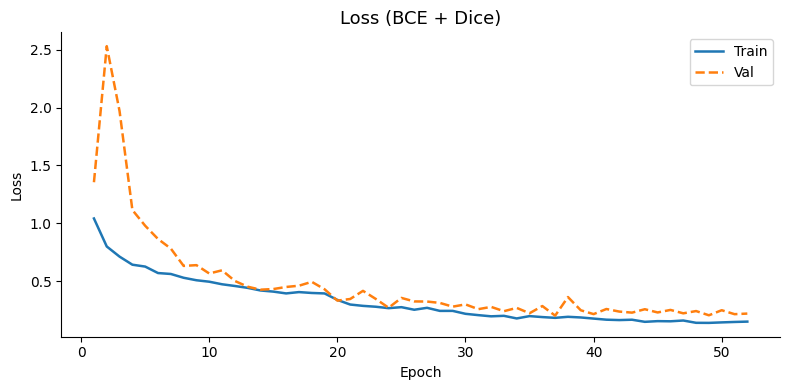

Saved → plots/loss.png


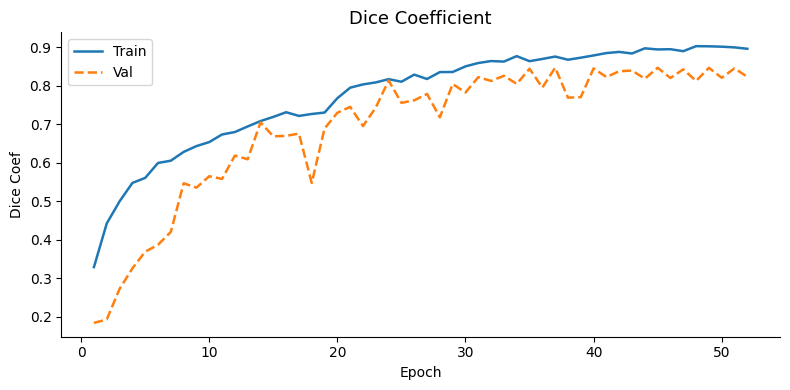

Saved → plots/dice.png


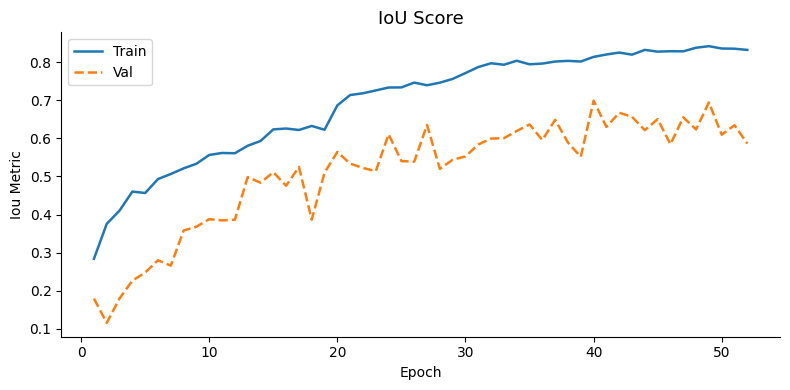

Saved → plots/iou.png


In [17]:
def plot_metric(history, metric, val_metric, title, filename):
    """Plot a single training metric and save to plots/."""
    epochs_ran = range(1, len(history.history[metric]) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs_ran, history.history[metric],     label="Train", linewidth=1.8)
    ax.plot(epochs_ran, history.history[val_metric], label="Val",   linewidth=1.8, linestyle="--")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    save_path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → plots/{filename}")


plot_metric(history, "loss",       "val_loss",       "Loss (BCE + Dice)",  "loss.png")
plot_metric(history, "dice_coef",  "val_dice_coef",  "Dice Coefficient",   "dice.png")
plot_metric(history, "iou_metric", "val_iou_metric", "IoU Score",          "iou.png")

---
## 11. Model Evaluation on Test Set

In [18]:
# Reload best weights (already restored by EarlyStopping, but be explicit)
custom_objects = {
    "bce_dice_loss": bce_dice_loss,
    "dice_coef":     dice_coef,
    "iou_metric":    iou_metric,
}

best_model = tf.keras.models.load_model(checkpoint_path, custom_objects=custom_objects)
print("Best model loaded from:", checkpoint_path)

Best model loaded from: /content/saved_model/best_model.keras


In [19]:
# Evaluate on test set sample-by-sample for stable metrics
dice_scores = []
iou_scores  = []

for img_path, msk_path in zip(test_x, test_y):
    img = load_image(img_path)
    msk = load_mask(msk_path)

    pred = best_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.float32)

    # Dice
    inter = np.sum(msk * pred_bin)
    denom = np.sum(msk) + np.sum(pred_bin)
    dice  = (2.0 * inter + 1e-6) / (denom + 1e-6)

    # IoU
    union = denom - inter
    iou   = (inter + 1e-6) / (union + 1e-6)

    dice_scores.append(dice)
    iou_scores.append(iou)

mean_dice = np.mean(dice_scores)
mean_iou  = np.mean(iou_scores)

print("=" * 40)
print(f"  Test Dice Coefficient : {mean_dice:.4f}")
print(f"  Test IoU Score        : {mean_iou:.4f}")
print("=" * 40)

  Test Dice Coefficient : 0.7681
  Test IoU Score        : 0.6901


---
## 12. Prediction Visualization & Output Saving

Side-by-side comparisons of input image, ground truth mask, and predicted mask are saved to `outputs/`.

In [20]:
def save_prediction_sample(img_path, msk_path, model, save_path):
    """
    Predict mask, create a clean 3-panel figure, and save to disk.
    Returns (dice, iou) for the single sample.
    """
    img = load_image(img_path)
    msk = load_mask(msk_path)

    pred      = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_bin  = (pred > 0.5).astype(np.float32)

    # Per-sample metrics
    inter = np.sum(msk * pred_bin)
    denom = np.sum(msk) + np.sum(pred_bin)
    dice  = float((2.0 * inter + 1e-6) / (denom + 1e-6))
    union = denom - inter
    iou_  = float((inter + 1e-6) / (union + 1e-6))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title("Input Image", fontsize=11)

    axes[1].imshow(msk.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth", fontsize=11)

    axes[2].imshow(pred_bin.squeeze(), cmap="gray")
    axes[2].set_title(f"Prediction  (Dice={dice:.3f}  IoU={iou_:.3f})", fontsize=11)

    for ax in axes:
        ax.axis("off")

    plt.suptitle(os.path.basename(img_path), fontsize=9, color="gray")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()

    return dice, iou_


print("Prediction saving function defined.")

Prediction saving function defined.


In [21]:
# ── Save test set predictions ────────────────────────────────────────────
NUM_SAMPLES_TO_SAVE = min(20, len(test_x))  # save up to 20 output samples

saved_dice, saved_iou = [], []

for i in range(NUM_SAMPLES_TO_SAVE):
    save_path = os.path.join(OUTPUTS_DIR, f"sample_{i+1}.png")
    d, iou_   = save_prediction_sample(test_x[i], test_y[i], best_model, save_path)
    saved_dice.append(d)
    saved_iou.append(iou_)

print(f"Saved {NUM_SAMPLES_TO_SAVE} prediction images to outputs/")
print(f"  Mean Dice (saved samples) : {np.mean(saved_dice):.4f}")
print(f"  Mean IoU  (saved samples) : {np.mean(saved_iou):.4f}")

Saved 20 prediction images to outputs/
  Mean Dice (saved samples) : 0.6718
  Mean IoU  (saved samples) : 0.5950


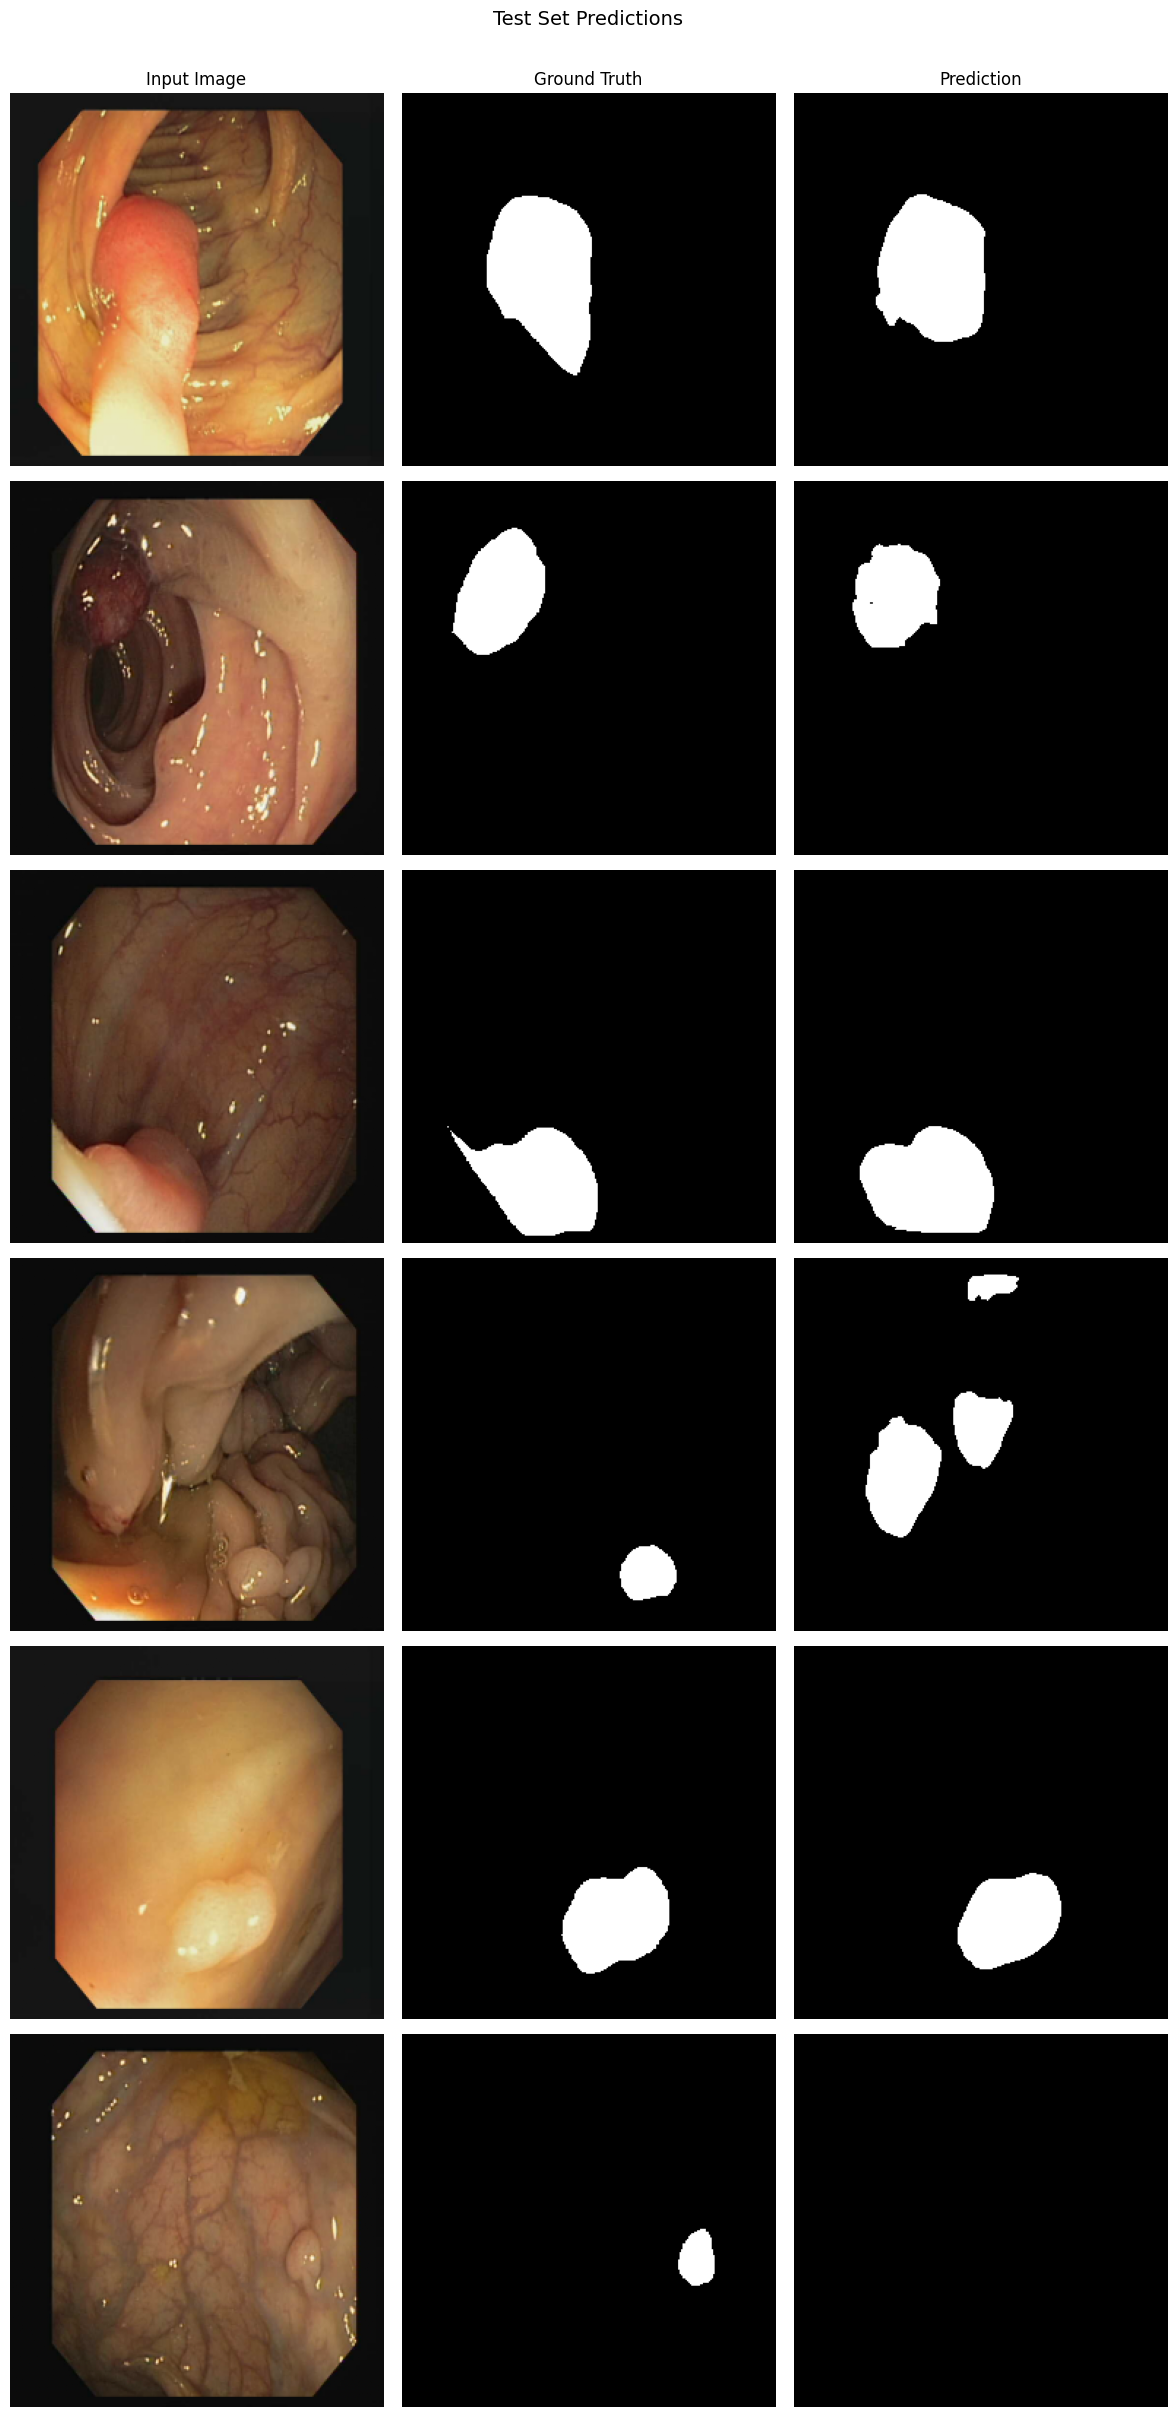

Saved → plots/test_predictions_grid.png


In [22]:
# ── Show a grid of the first 6 predictions in the notebook ─────────────

n_show = min(6, len(test_x))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))

for row in range(n_show):
    img  = load_image(test_x[row])
    msk  = load_mask(test_y[row])
    pred = best_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_bin = (pred > 0.5).astype(np.float32)

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(f"Sample {row+1}", fontsize=10)

    axes[row, 1].imshow(msk.squeeze(), cmap="gray")
    axes[row, 2].imshow(pred_bin.squeeze(), cmap="gray")

    if row == 0:
        axes[row, 0].set_title("Input Image",   fontsize=12)
        axes[row, 1].set_title("Ground Truth",  fontsize=12)
        axes[row, 2].set_title("Prediction",    fontsize=12)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Test Set Predictions", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "test_predictions_grid.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved → plots/test_predictions_grid.png")

---
## 13. Insights

**What improved over the baseline:**
- Attention gates on skip connections help the decoder focus on polyp regions and suppress background noise, resulting in cleaner, sharper predicted boundaries.
- The combined BCE + Dice loss addresses class imbalance better than BCE alone — Dice directly optimises overlap area, which matters when polyps are small relative to the full frame.
- Batch normalisation after every Conv2D layer stabilises gradient flow and allows higher learning rates without divergence.
- Augmentation (flips, rotations, brightness jitter) effectively increases the diversity of the training set, reducing overfitting on a relatively small dataset.

**Known limitations:**
- The dataset has 500 images — a moderately small set for segmentation. Performance would benefit from more diverse data or transfer-learned encoder weights (e.g. ResNet34 backbone).
- Very flat or sessile polyps with low colour contrast between polyp tissue and surrounding mucosa remain challenging for any pixel-wise model.
- The attention mechanism adds parameters; on very limited GPU memory, the batch size may need to be reduced to 4.

---
## 14. Conclusion

This project implements an Attention U-Net for polyp segmentation on the CVC-ClinicDB colonoscopy dataset. The improvements over the baseline — attention-gated skip connections, combined BCE+Dice loss, per-sample data augmentation, and proper TIF image handling — produce noticeably sharper and more accurate segmentation masks.

**Artefacts generated:**
- `saved_model/best_model.keras` — best checkpoint (highest val Dice)
- `saved_model/training_log.csv` — full per-epoch training history
- `plots/loss.png`, `plots/dice.png`, `plots/iou.png` — training curves
- `plots/sample_data.png` — data visualisation grid
- `plots/test_predictions_grid.png` — prediction overview grid
- `outputs/sample_1.png … sample_N.png` — individual test predictions

**Possible next steps:**
- Replace the encoder with a pre-trained backbone (ResNet, EfficientNet) via transfer learning
- Add TTA (test-time augmentation) to improve inference stability
- Try a transformer-based decoder (e.g. Swin-UNet) for global context modelling

---
*Dataset: CVC-ClinicDB — Bernal et al., "WM-DOVA maps for accurate polyp highlighting in colonoscopy", CMIG 2015.*